Размер выборки: 100
  Выборочное среднее: 3.9942 (Теоретическое: 4)
  Отклонение среднего: 0.0058
  Выборочная дисперсия: 6.8382 (Теоретическое: 8)
  Отклонение дисперсии: 1.1618

Размер выборки: 1000
  Выборочное среднее: 4.0179 (Теоретическое: 4)
  Отклонение среднего: 0.0179
  Выборочная дисперсия: 7.8314 (Теоретическое: 8)
  Отклонение дисперсии: 0.1686

Размер выборки: 10000
  Выборочное среднее: 4.0026 (Теоретическое: 4)
  Отклонение среднего: 0.0026
  Выборочная дисперсия: 7.9074 (Теоретическое: 8)
  Отклонение дисперсии: 0.0926

Размер выборки: 100000
  Выборочное среднее: 4.0128 (Теоретическое: 4)
  Отклонение среднего: 0.0128
  Выборочная дисперсия: 7.9657 (Теоретическое: 8)
  Отклонение дисперсии: 0.0343



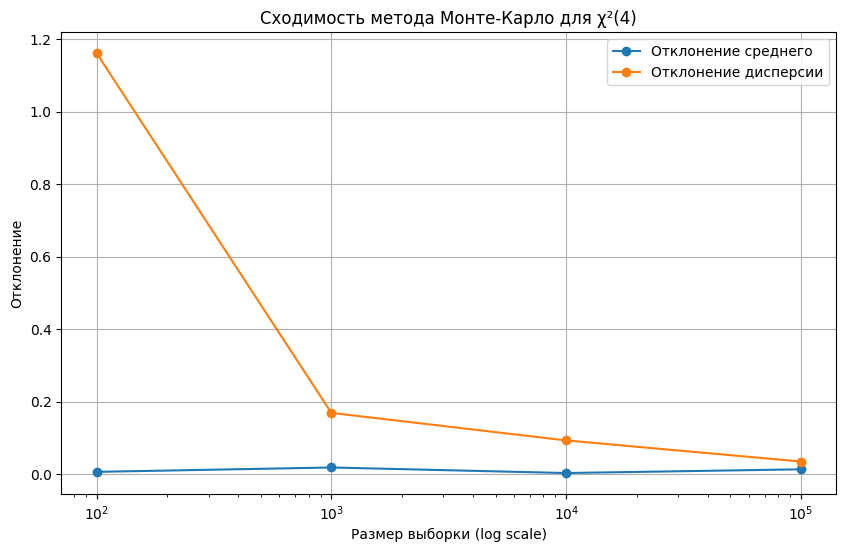

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def generate_chi_squared(l, num_samples):
    """
    Генерация выборки из χ²(2l) через сумму l показательных величин Exp(0.5).
    """
    # Параметры гамма-распределения Gam(l, 0.5)
    alpha = l
    beta = 0.5

    # Генерация num_samples x l равномерных чисел
    uniforms = np.random.uniform(0, 1, (num_samples, alpha))

    # Преобразование в Exp(0.5)
    exponentials = -2 * np.log(uniforms)

    # Суммирование l величин
    chi_squared_samples = np.sum(exponentials, axis=1)

    return chi_squared_samples

def run_tests(l, test_sizes):
    """
    Проведение тестов для разных размеров выборки.

    Параметры:
    - l (int): Натуральное число (n = 2l).
    - test_sizes (list): Список размеров выборок (например, [100, 1000, 10000]).

    Возвращает:
    - results (dict): Словарь с результатами для каждой выборки.
    """
    results = {}
    theoretical_mean = 2 * l    # Теоретическое среднее для χ²(2l)
    theoretical_var = 4 * l     # Теоретическая дисперсия для χ²(2l)

    for size in test_sizes:
        # Генерация выборки
        data = generate_chi_squared(l, size)

        # Вычисление выборочных характеристик
        sample_mean = np.mean(data)
        sample_var = np.var(data, ddof=1)

        # Сохранение результатов
        results[size] = {
            "sample_mean": sample_mean,
            "theoretical_mean": theoretical_mean,
            "sample_var": sample_var,
            "theoretical_var": theoretical_var,
            "mean_diff": abs(sample_mean - theoretical_mean),
            "var_diff": abs(sample_var - theoretical_var)
        }

    return results

def plot_results(results):
    """
    Визуализация отклонений выборочных характеристик от теоретических.

    Параметры:
    - results (dict): Результаты тестов.
    """
    sizes = list(results.keys())
    mean_diffs = [results[size]["mean_diff"] for size in sizes]
    var_diffs = [results[size]["var_diff"] for size in sizes]

    plt.figure(figsize=(10, 6))
    plt.plot(sizes, mean_diffs, marker='o', label='Отклонение среднего')
    plt.plot(sizes, var_diffs, marker='o', label='Отклонение дисперсии')
    plt.xscale('log')
    plt.xlabel('Размер выборки (log scale)')
    plt.ylabel('Отклонение')
    plt.title(f'Сходимость метода Монте-Карло для χ²({2 * l})')
    plt.legend()
    plt.grid(True)
    plt.show()

# Параметры
l = 2                           # Натуральное число (n = 2l = 4)
test_sizes = [100, 1000, 10000, 100000]  # Размеры выборок для тестов

# Запуск тестов
results = run_tests(l, test_sizes)

# Вывод результатов
for size, res in results.items():
    print(f"Размер выборки: {size}")
    print(f"  Выборочное среднее: {res['sample_mean']:.4f} (Теоретическое: {res['theoretical_mean']})")
    print(f"  Отклонение среднего: {res['mean_diff']:.4f}")
    print(f"  Выборочная дисперсия: {res['sample_var']:.4f} (Теоретическое: {res['theoretical_var']})")
    print(f"  Отклонение дисперсии: {res['var_diff']:.4f}\n")

# Визуализация
plot_results(results)